# День 08. Упражнение 05
# Кластеризация

## 0. Импорты

In [1]:
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 1. Предобработка

1. Прочитай файл [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) в DataFrame.
2. Удали колонку `pageviews`, мы будем кластеризовать пользователей только по количеству коммитов и их средней разнице.

In [3]:
df = pd.read_csv('../data/regression.csv', usecols=['uid', 'num_commits', 'AVG(diff)'])
df

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667
5,user_19,118,-98.750000
6,user_21,65,-95.500000
7,user_25,79,-92.600000
8,user_28,60,-86.400000
9,user_3,18,-105.400000


In [4]:
df.set_index('uid', inplace=True)
df

,num_commits,AVG(diff)
uid,,
user_1,62,-64.400000
user_10,20,-74.800000
user_14,61,-159.000000
user_17,51,-61.600000
user_18,5,-5.666667
user_19,118,-98.750000
user_21,65,-95.500000
user_25,79,-92.600000
user_28,60,-86.400000


## 2. KMeans

1. Ознакомься с документацией и разберись, как работает этот алгоритм.
2. Используй этот алгоритм для создания кластеров с параметрами `random_state=21` и `n_clusters=3`.
3. Визуализируй данные на `scatter plot`.
4. Попробуй разные значения `n_clusters` и посмотри, как изменится твой график.
5. Вычисли `silhouette_score` (см. документацию по метрике).

In [5]:
kmeans = KMeans(n_clusters=3, random_state=21)
labels_kmeans = kmeans.fit_predict(df)

In [6]:
def plot_clusters(df, labels, title):
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df.iloc[:, 0], y=df.iloc[:, 1], hue=labels, palette='tab10', s=80, alpha=0.5)
    plt.title(title)
    plt.legend(title='Кластер', title_fontsize=12, fontsize=10)
    plt.tight_layout()
    plt.show()

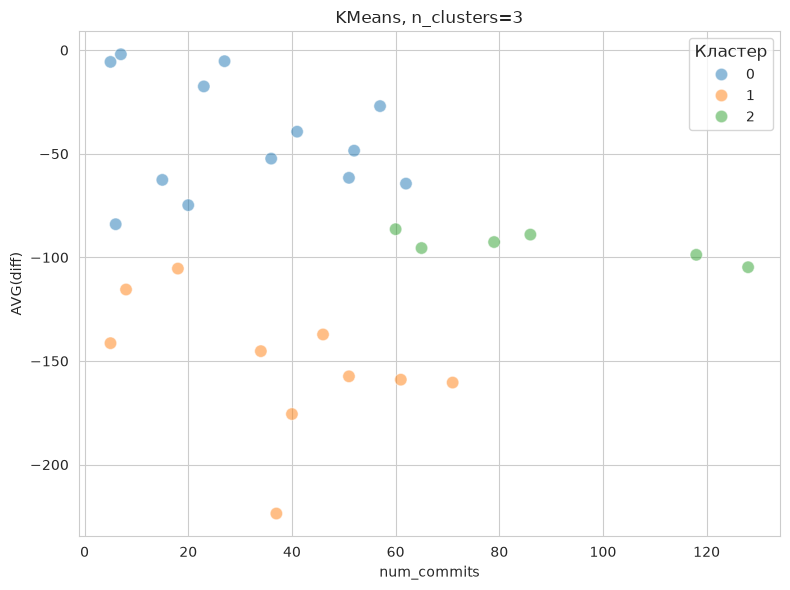

n_clusters=3, silhouette_score: 0.4454402135233297


In [7]:
plot_clusters(df, labels_kmeans, title=f'KMeans, n_clusters=3')
score_kmeans = silhouette_score(df, labels_kmeans)
print(f'n_clusters=3, silhouette_score: {score_kmeans}')

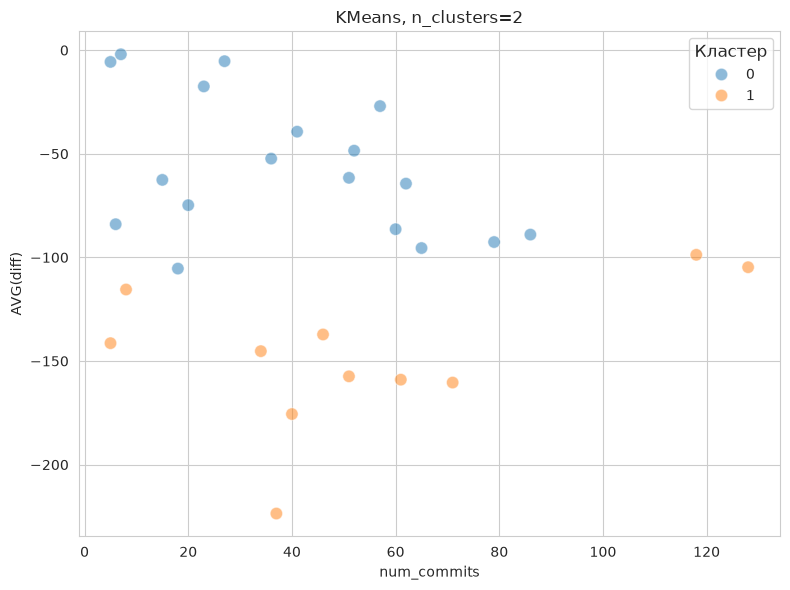

n_clusters=2, silhouette_score: 0.4194920562377423


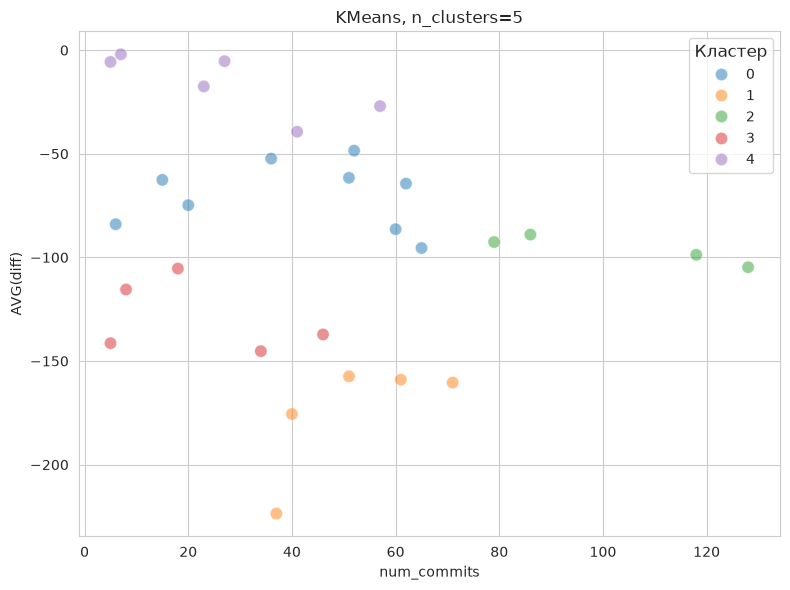

n_clusters=5, silhouette_score: 0.3521030626149593


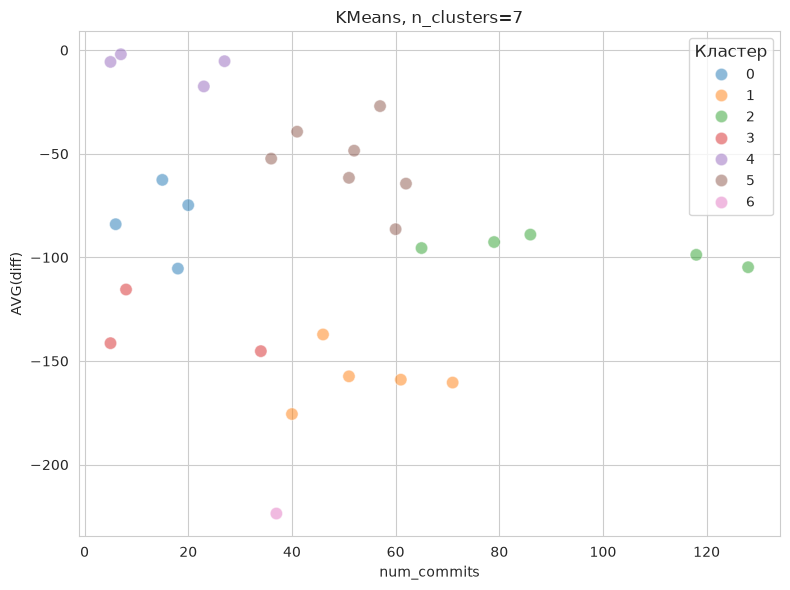

n_clusters=7, silhouette_score: 0.39637476619843964


In [8]:
for n in [2, 5, 7]:
    labels_n = KMeans(n_clusters=n, random_state=21).fit_predict(df)
    plot_clusters(df, labels_n, title=f'KMeans, n_clusters={n}')
    score = silhouette_score(df, labels_n)
    print(f'n_clusters={n}, silhouette_score: {score}')

## 3. DBSCAN

1. Ознакомься с документацией и разберись, как работает этот алгоритм.
2. Используй этот алгоритм для создания кластеров с параметрами `eps=20` и `min_samples=2`.
3. Визуализируй данные на `scatter plot`.
4. Попробуй разные значения `eps` и `min_samples` и посмотри, как изменится твой график.
5. Вычисли `silhouette_score` (см. документацию по метрике).

In [9]:
dbscan = DBSCAN(eps=20, min_samples=2)
labels_dbscan = dbscan.fit_predict(df)

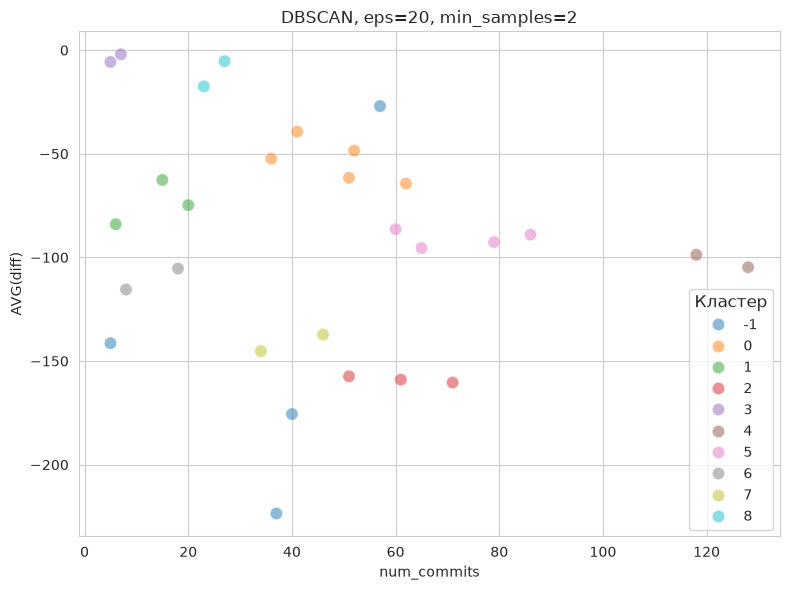

eps=20, min_samples=2, silhouette_score: 0.38339641455696616


In [10]:
plot_clusters(df, labels_dbscan, title=f'DBSCAN, eps=20, min_samples=2')
score_dbscan = silhouette_score(df, labels_dbscan)
print(f'eps=20, min_samples=2, silhouette_score: {score_dbscan}')

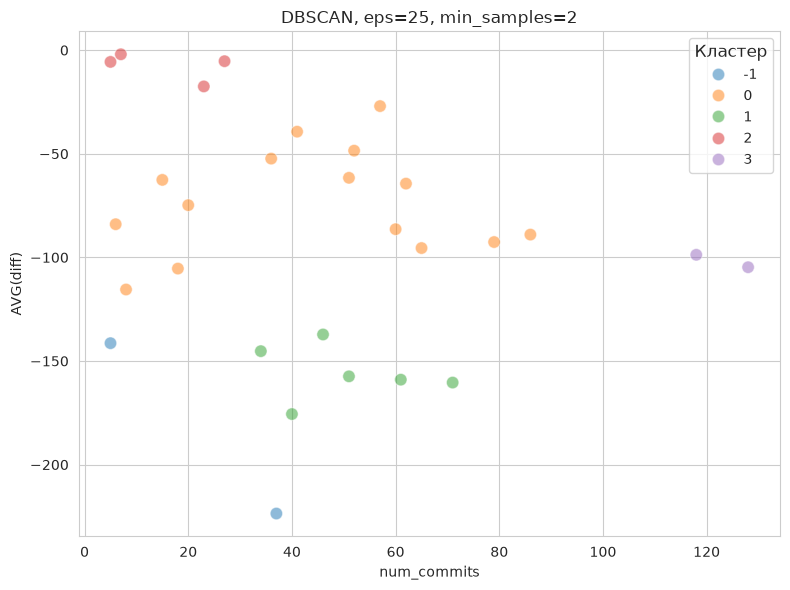

eps=25, min_samples=2, silhouette_score: 0.34388947016930727


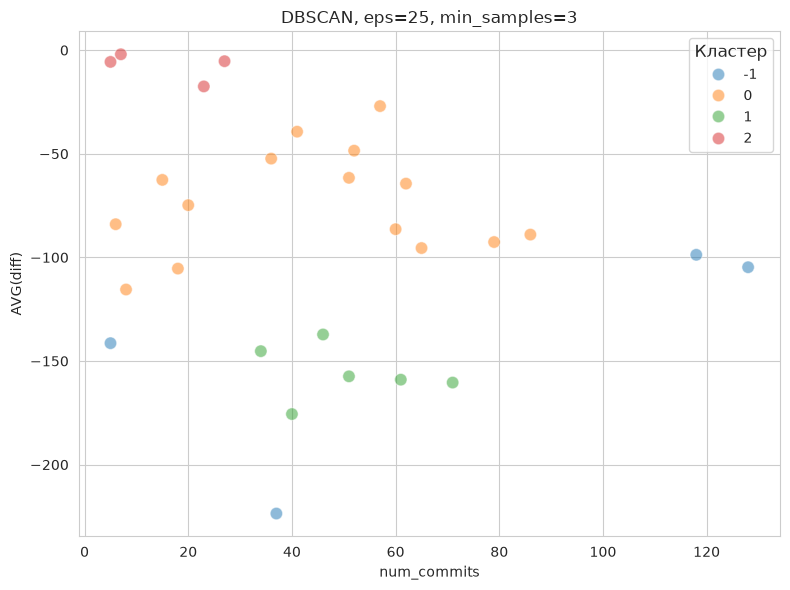

eps=25, min_samples=3, silhouette_score: 0.3233351898184616


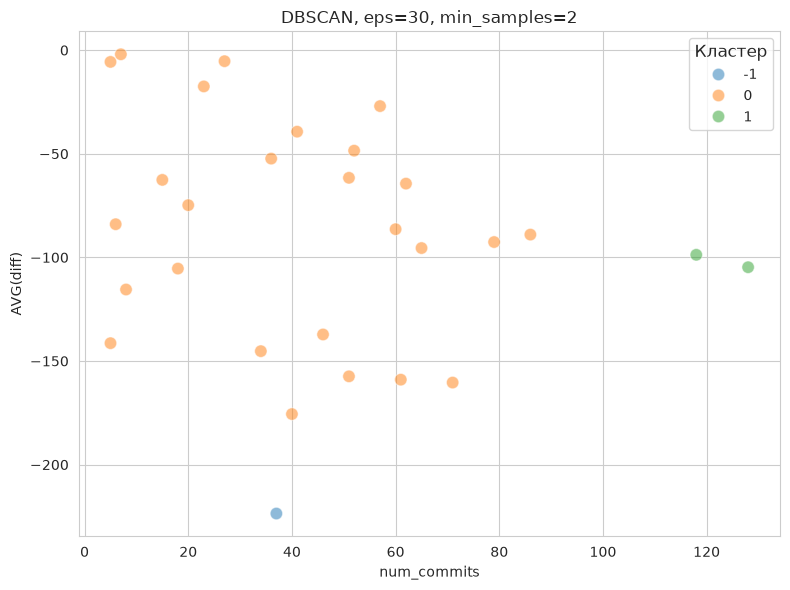

eps=30, min_samples=2, silhouette_score: 0.19881722125199422


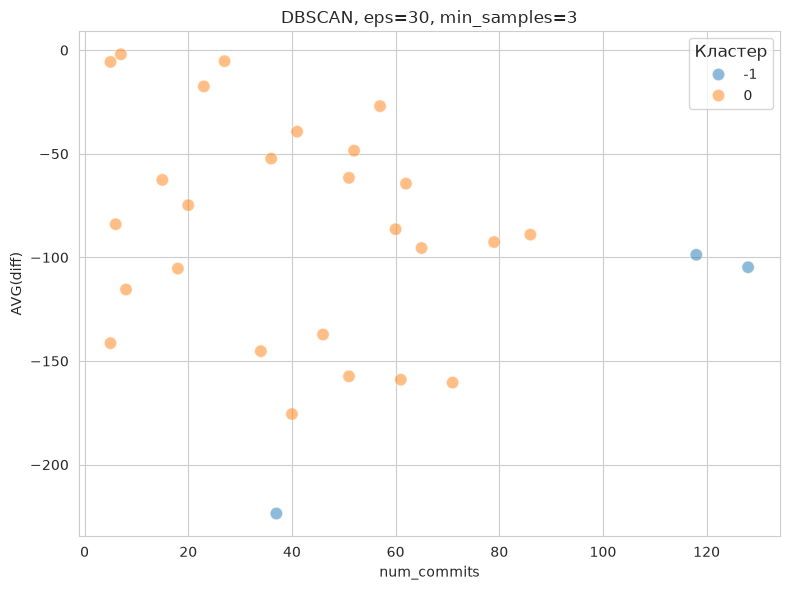

eps=30, min_samples=3, silhouette_score: 0.2936796540926391


In [11]:
for eps in [25, 30]:
    for min_samples in [2, 3]:
        labels_test = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(df)
        plot_clusters(df, labels_test, title=f'DBSCAN, eps={eps}, min_samples={min_samples}')
        score = silhouette_score(df, labels_test)
        print(f'eps={eps}, min_samples={min_samples}, silhouette_score: {score}')

## 4. Иерархическая кластеризация (AgglomerativeClustering)

1. Используй этот алгоритм для создания кластеров с параметром `n_clusters=5`.
2. Визуализируй данные на `scatter plot`.
3. Попробуй разные значения `n_clusters` и посмотри, как изменится твой график.
4. Вычисли `silhouette_score`.
5. Визуализируй `dendrogram`.

In [12]:
agg_clust = AgglomerativeClustering(n_clusters=5)
labels_agg_clust = agg_clust.fit_predict(df)

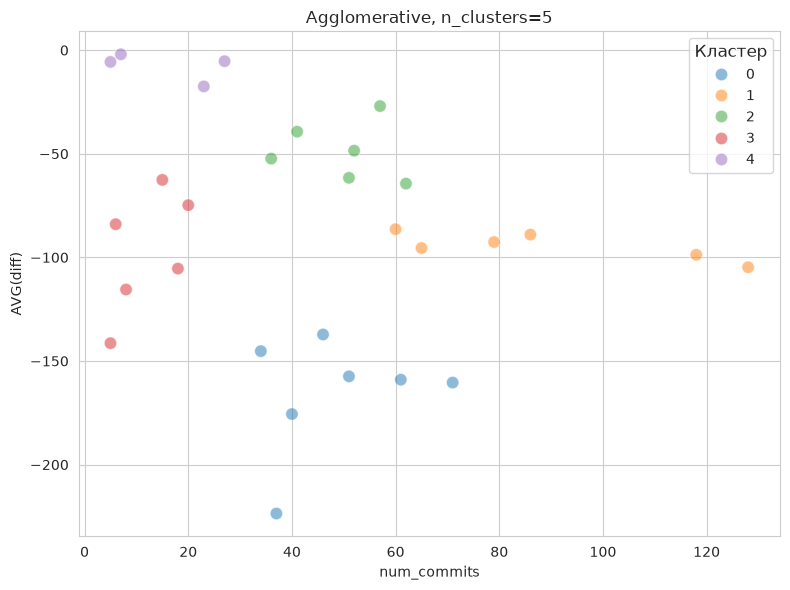

n_clusters=5, silhouette_score: 0.46383015199381467


In [13]:
plot_clusters(df, labels_agg_clust, title='Agglomerative, n_clusters=5')
score_agg_clust = silhouette_score(df, labels_agg_clust)
print(f'n_clusters=5, silhouette_score: {score_agg_clust}')

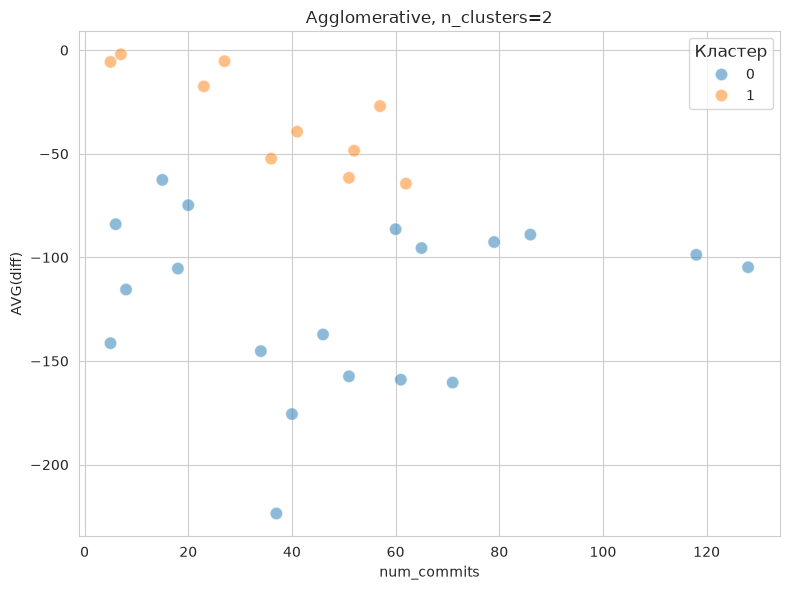

n_clusters=2, silhouette_score: 0.35902490572221984


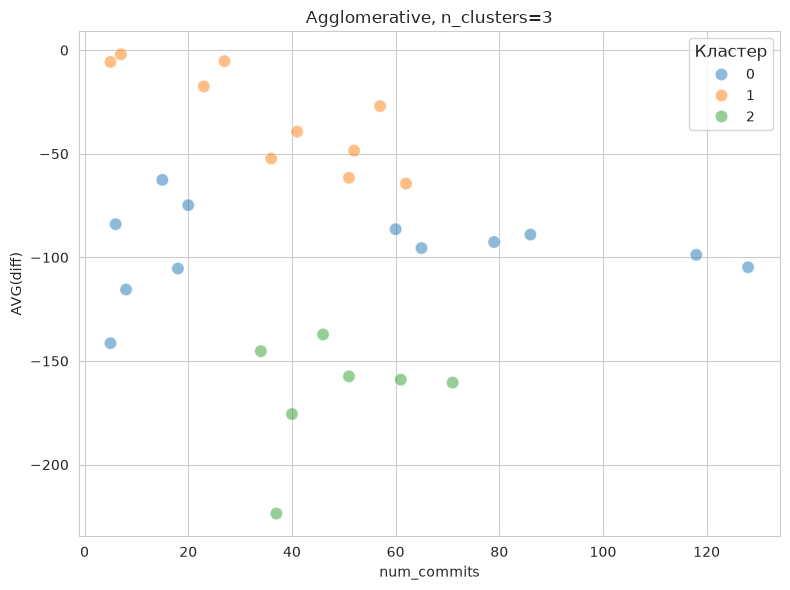

n_clusters=3, silhouette_score: 0.3390493703444805


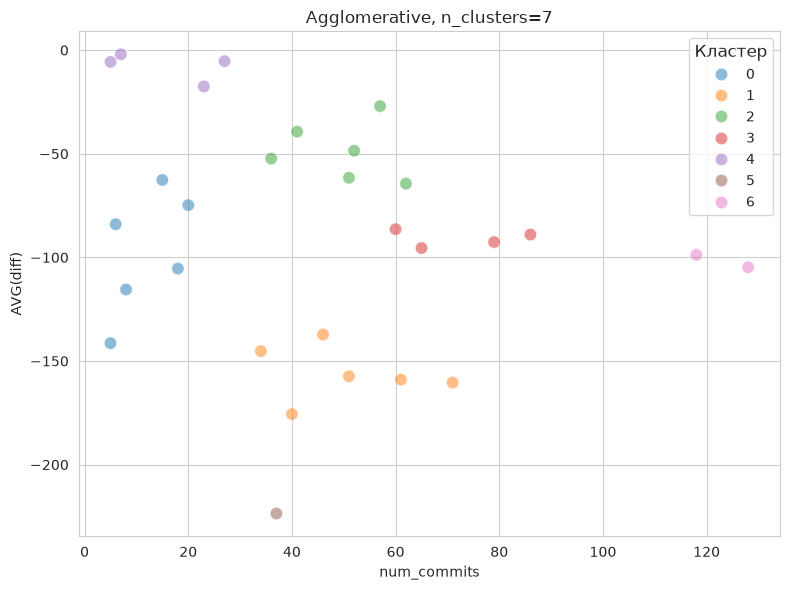

n_clusters=7, silhouette_score: 0.4865808853184314


In [14]:
for n in [2, 3, 7]:
    labels_n = AgglomerativeClustering(n_clusters=n).fit_predict(df)
    plot_clusters(df, labels_n, title=f'Agglomerative, n_clusters={n}')
    score_n = silhouette_score(df, labels_n)
    print(f'n_clusters={n}, silhouette_score: {score_n}')

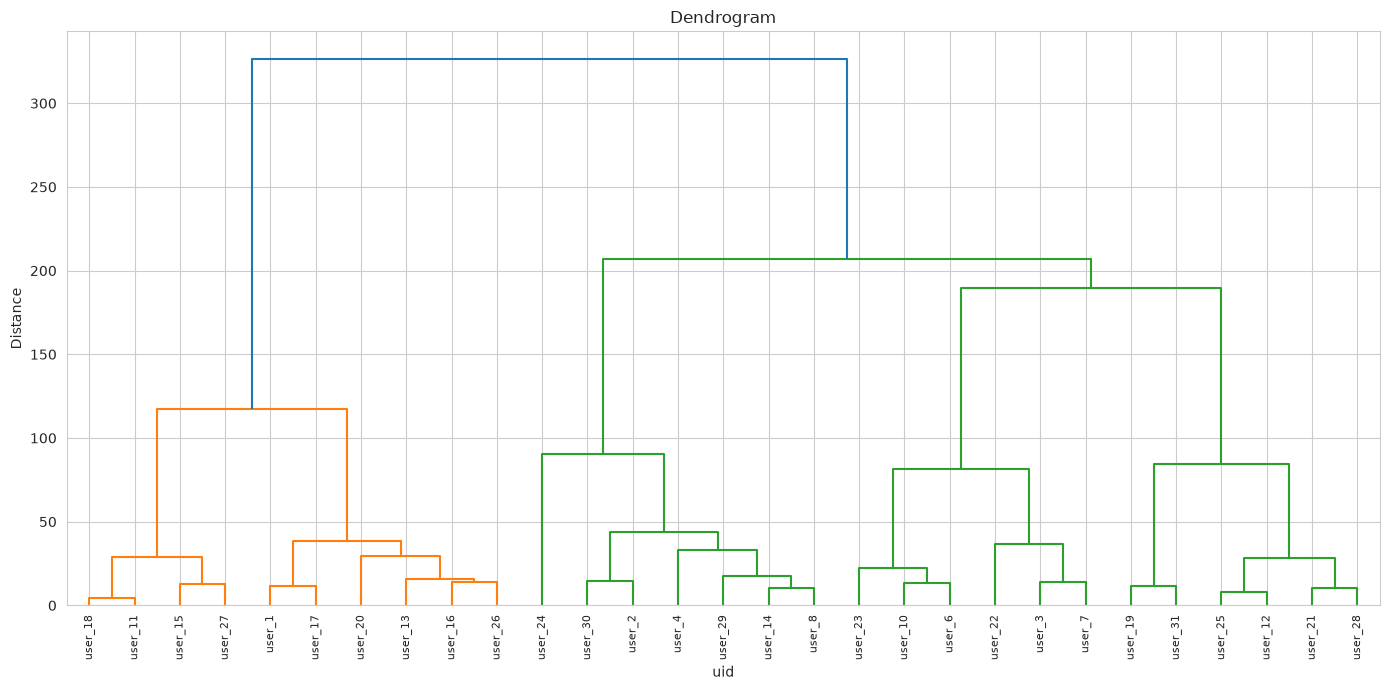

In [15]:
linkage_matrix = linkage(df, method='ward')
plt.figure(figsize=(14, 7))
dendrogram(linkage_matrix, labels=df.index.tolist())
plt.title('Dendrogram')
plt.xlabel('uid')
plt.ylabel('Distance')
plt.xticks(fontsize=8, rotation=90)
plt.tight_layout()
plt.show()

## 5. Функция

Напиши функцию, которая:
1. Принимает аргументы: класс модели кластеризации, её параметры, имя параметра для оптимизации и диапазон значений этого параметра.
2. Перебирает разные значения из заданного диапазона и вычисляет `silhouette_score` для каждого значения.
3. Определяет лучшее значение параметра в диапазоне.
4. Возвращает два подграфика:

- первый показывает, как `silhouette_score` меняется в зависимости от значения параметра;
- второй визуализирует данные на `scatter plot` с использованием модели кластеризации с лучшим найденным значением параметра.

In [16]:
def find_best_param(model_class, model_params, param_name, param_range, df):
    scores = []

    for value in param_range:
        params = {**model_params, param_name: value}
        labels = model_class(**params).fit_predict(df)
        score = silhouette_score(df, labels)
        scores.append(score)

    best_idx = scores.index(max(scores))
    best_value = param_range[best_idx]
    best_params = {**model_params, param_name: best_value}
    best_labels = model_class(**best_params).fit_predict(df)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].plot(list(param_range), scores, marker='o', color='lightblue')
    axes[0].set_xlabel(param_name)
    axes[0].set_ylabel('silhouette_score')
    axes[0].set_title(f'Silhouette score vs {param_name}')

    sns.scatterplot(x=df.iloc[:, 0], y=df.iloc[:, 1], hue=best_labels, palette='tab10', s=80, alpha=0.5, ax=axes[1])
    axes[1].set_title(f'{model_class.__name__}, {param_name}={best_value}')
    axes[1].legend(title='Кластер', title_fontsize=12, fontsize=10)

    plt.tight_layout()
    plt.show()

    return best_value, max(scores)

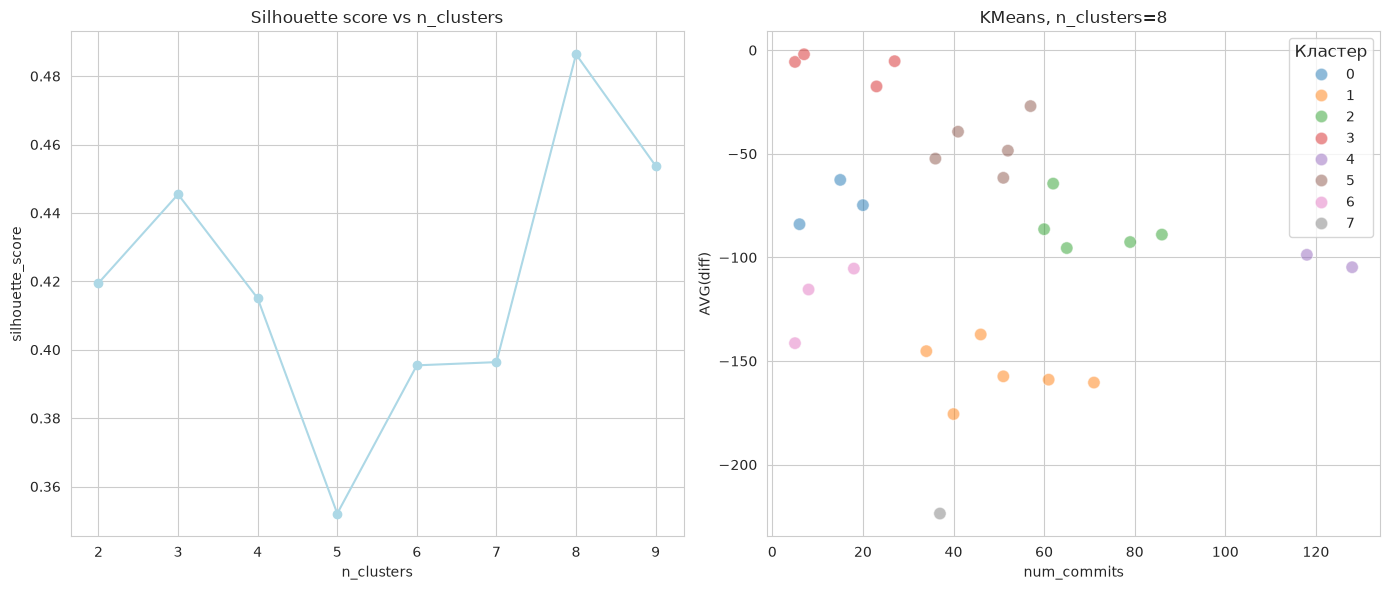

In [17]:
best_n, best_score = find_best_param(KMeans, {'random_state': 21}, 'n_clusters', range(2, 10), df)

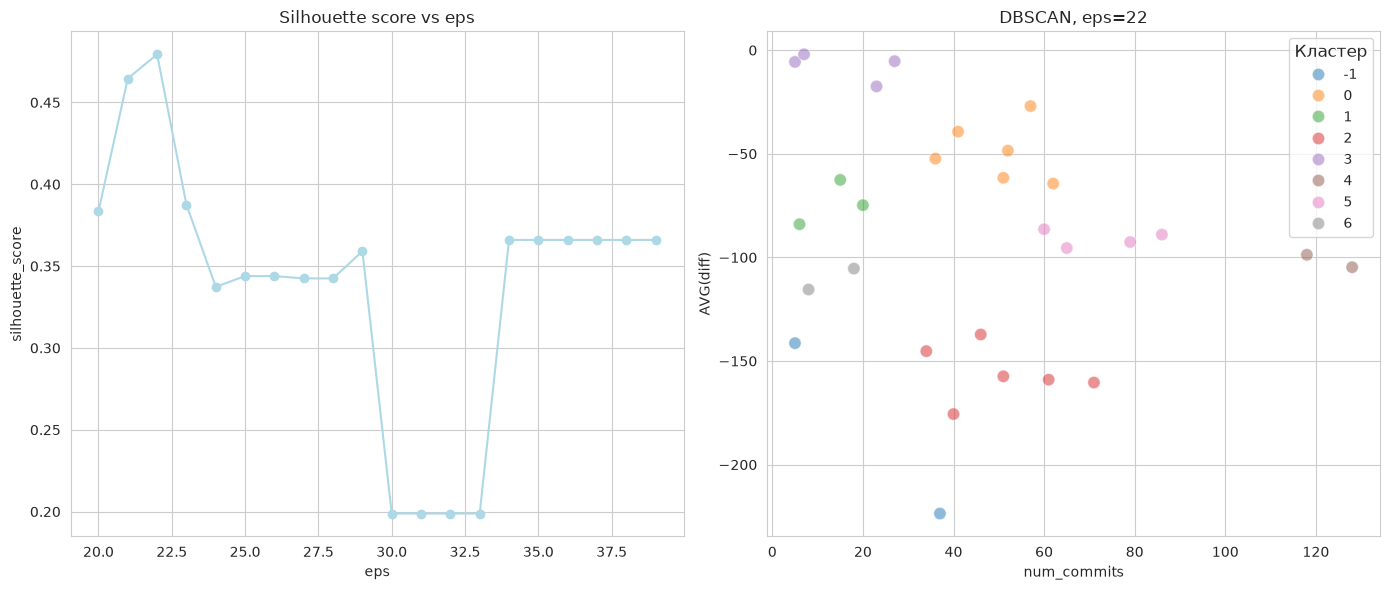

In [18]:
best_eps, best_score = find_best_param(DBSCAN, {'min_samples': 2}, 'eps', range(20, 40), df)

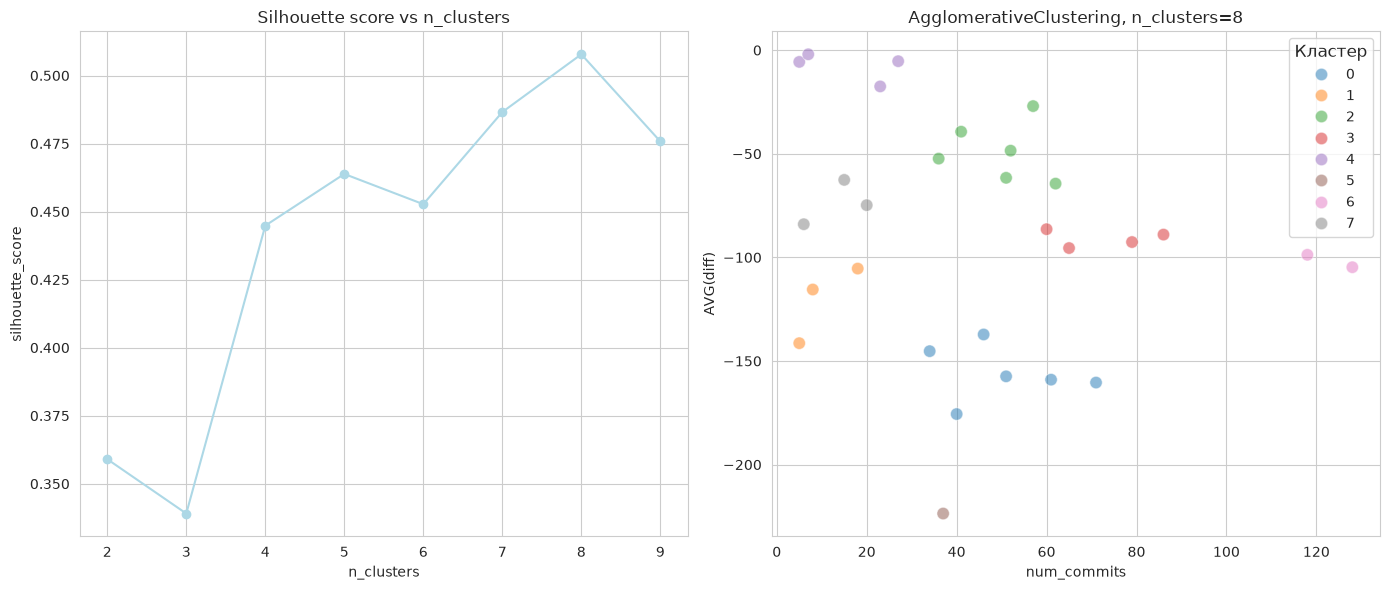

In [19]:
best_n, best_score = find_best_param(AgglomerativeClustering, {}, 'n_clusters', range(2, 10), df)